#Imports

In [1]:
from PIL import Image
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.math import confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from PIL import Image
import io
from google.colab import files




## Subir modelo

In [25]:
def upload_model(new_path):
  new_model = tf.keras.models.load_model(new_path)
  return new_model


## Subir imagen

In [2]:
def evaluate_image(image, model):
  image = image.resize((128, 128))
  image = np.array(image)
  image = image / 255.0
  image = np.expand_dims(image, axis=0)
  prediction = model.predict(image)
  return prediction

In [3]:
def upload_image():
  uploaded = files.upload()
  file_name = list(uploaded.keys())[0]
  image = Image.open(io.BytesIO(uploaded[file_name]))
  image.show()
  return image


# Obtener Path de google drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
%cd "/content/drive/MyDrive/RecoCubes/"
!ls

/content/drive/MyDrive/RecoCubes
'diamond_ore_test (1).jpg'  'glostone_group (2).jfif'
'diamond_ore_test (2).jpg'  'glostone_group (3).jfif'
'diamond_ore_test (3).jpg'  'glostone_group (4).jfif'
'diamond_ore_test (4).jpg'   glostone_group.jfif
'diamond_ore_test (5).jpg'   images
'diamond_ore_test (6).jpg'  'Potone_Diamond_Ore (1).png'
'diamond_ore_test (7).jpg'  'Potone_Diamond_Ore (2).png'
 diamond_ore_test.jpg	    'Potone_Diamond_Ore (3).png'
'glostone_group (1).jfif'    Potone_Diamond_Ore.png


# Preprocesamiento de datos

In [6]:
def get_images_info_to_chart(test_generator):
  class_names = list(test_generator.class_indices.keys())
  print("Clases: ", class_names)
  all_images = []
  all_labels = []
  for index in range(len(test_generator)):
      images, labels = test_generator[index]
      all_images.append(images)
      all_labels.append(labels)
  return all_images, all_labels, class_names


In [7]:
def create_predictions(all_images, all_labels, model):
  test_images = np.concatenate(all_images)
  test_labels = np.concatenate(all_labels)

  predictions = model.predict(test_images)
  classes_x = np.argmax(predictions, axis=1)
  test_labels_indices = np.argmax(test_labels, axis=1)
  return classes_x, test_labels_indices


In [8]:
def create_matrix(number_classes, all_labels, all_classes):
  matrix = np.zeros((number_classes, number_classes), dtype=int)
  for index in range (len(all_classes)):
    label = all_labels[index]
    classs = all_classes[index]
    matrix[label][classs] += 1
  return matrix

In [9]:
def plot_matrix(matrix, model, number_classes, class_names):
  fig, ax = plt.subplots(figsize=(10, 8))
  im = ax.imshow(matrix, cmap=plt.cm.Blues)
  plt.colorbar(im)

  ax.set(
      xticks=np.arange(number_classes),
      yticks=np.arange(number_classes),
      xticklabels=class_names,
      yticklabels=class_names,
      xlabel='Predicción',
      ylabel='Real',
      title='Matriz de Confusión - ' + model
  )
  plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
  for i in range(number_classes):
    for j in range(number_classes):
      ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
        color="white" if matrix[i, j] > matrix.max()/2 else "black")

  plt.tight_layout()
  plt.show()

In [10]:
def predict_image(model, generator):
    class_names = {}
    for name, index in generator.class_indices.items():
      class_names[index] = name

    image = upload_image()

    prediction = evaluate_image(image, model)

    class_index = np.argmax(prediction)
    class_name = class_names[class_index]
    confidance = prediction[0][class_index] * 100

    print(f"\nClase predicha: {class_name}")
    print(f"Confianza:      {confidance:.1f}%")
    print(f"\nProbabilidades por clase:")
    for index, probability in enumerate(prediction[0]):
        print(f"  {class_names[index]}: {probability*100:.1f}%")

## Validar tamaños

In [ ]:
def print_images_size_summary(sizes, clases_info):

  print("="*60)
  print("TAMAÑOS DE IMAGEN EN EL DATASET")
  print("="*60)

  contador = Counter(sizes)
  print(f"\nTotal imágenes analizadas: {len(sizes)}")
  print(f"Cantidad de tamaños diferentes: {len(contador)}")
  print(f"\nDistribución de tamaños:")
  for tamaño, cantidad in contador.most_common():
      print(f"  {tamaño[0]}x{tamaño[1]} píxeles: {cantidad} imágenes")

  print(f"\n{'='*60}")
  print("TAMAÑOS POR CLASE")
  print("="*60)
  for classes, sizes_clase in clases_info.items():
      count_class = Counter(sizes_clase)
      if len(count_class) == 1:
          size = list(count_class.keys())[0]
          print(f"{classes}: TODAS son {size[0]}x{size[1]}")
      else:
          print(f"{classes}: tiene {len(count_class)} tamaños diferentes")
          for s, c in count_class.items():
              print(f"      {s[0]}x{s[1]}: {c} imágenes")


In [ ]:
def get_size_images(base_dir):
  sizes = []
  clases_info = {}

  for clase in os.listdir(base_dir):
      clase_path = os.path.join(base_dir, clase)
      if os.path.isdir(clase_path):
          clase_sizes = []
          for img_name in os.listdir(clase_path):
              img_path = os.path.join(clase_path, img_name)
              try:
                  with Image.open(img_path) as img:
                      sizes.append(img.size)
                      clase_sizes.append(img.size)
              except:
                  pass
          clases_info[clase] = clase_sizes
  print_images_size_summary(sizes, clases_info)


In [ ]:
base_dir = 'images/train'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 630
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 630 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
netherrack: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [ ]:
base_dir = 'images/test'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
brick: TODAS son 128x128
emerald_block: TODAS son 128x128
diamond_ore: TODAS son 128x128
iron_ore: TODAS son 128x128
glowstone: TODAS son 128x128
gold_ore: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [ ]:
base_dir = 'images/validation'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
sand: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128


## Data Augmentation

In [11]:
base_dir = 'images'
train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir, 'test')
validation_dir = os.path.join(base_dir, 'validation')

Criterios:


1.   Rotación aleatoria -30 y +30
2.   Reflejo horizontal
3.   Traslación en X hasta +- 10 pixeles
4.   Traslación en Y hasta +- 10 pixeles
5.   Escalamiento entre 0.9 y 1.0


Image augmentation para el modelo 1

In [12]:
path = "/content/drive/MyDrive/RecoCubes/images"
train_datagen1 = ImageDataGenerator(
		 rescale = 1./255,
		 )

train_generator1 = train_datagen1.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 9,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
              save_prefix='aug',
              save_format='png'
							)

Found 630 images belonging to 9 classes.


image augmentation para el modelo 2

In [13]:
path = "/content/drive/MyDrive/RecoCubes/images"
train_datagen2 = ImageDataGenerator(
		 rescale = 1./255,
		 rotation_range=30,
		 horizontal_flip=True,
		 width_shift_range=10/128,
		 height_shift_range=10/128,
		 zoom_range=0.1,
		 )

train_generator2 = train_datagen2.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 9,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
              save_prefix='aug',
              save_format='png'
							)

Found 630 images belonging to 9 classes.


# Confirmación del Data augmentation

(9, 128, 128, 3)
[[0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]


<Figure size 640x480 with 0 Axes>

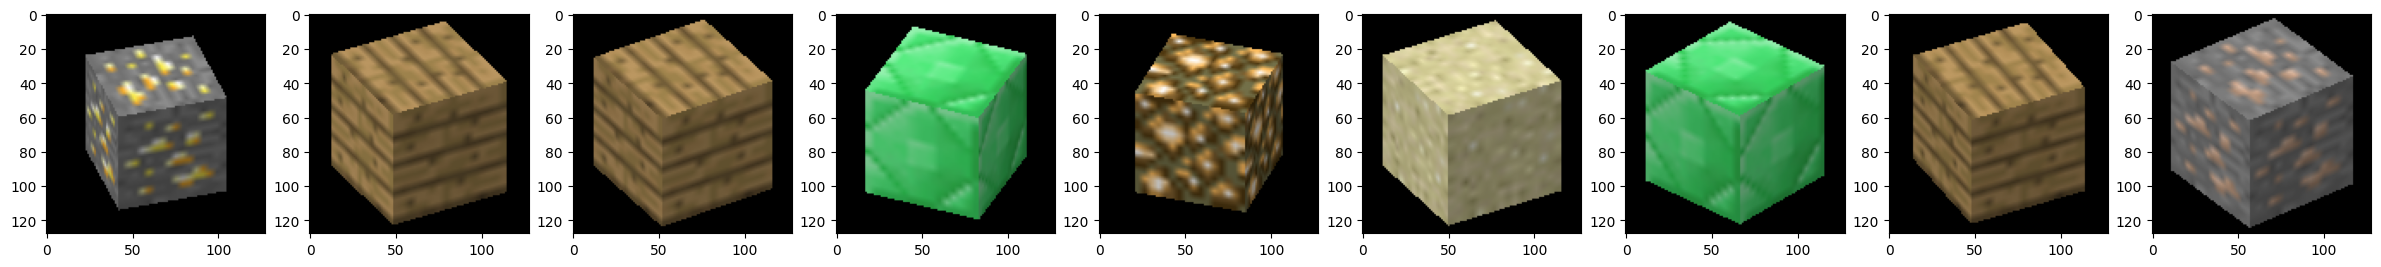

In [15]:
images , labels = train_generator1[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

(9, 128, 128, 3)
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]


<Figure size 640x480 with 0 Axes>

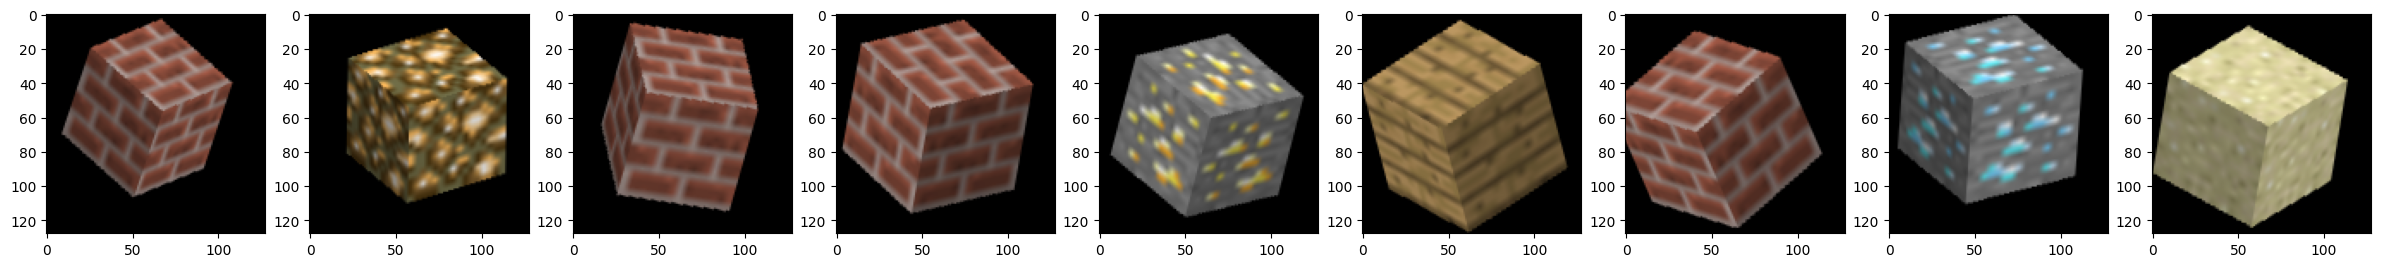

In [ ]:
images , labels = train_generator2[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

## Guardar Modelo

In [16]:

checkpoint_path_best = base_dir + "/checkpoint_m1/checkpoint.weights.h5"

checkpoint_best = ModelCheckpoint(filepath= checkpoint_path_best,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

In [ ]:

checkpoint_path_best2 = base_dir + "/checkpoint_m1/checkpoint2.weights.h5"

checkpoint_best2 = ModelCheckpoint(filepath= checkpoint_path_best2,
                                  save_weights_only = False,
                                  save_freq = "epoch",
                                  monitor = "val_accuracy",
                                  save_best_only = True,
                                  verbose = 1)

Modelo 1:

In [17]:


model1 = models.Sequential()
model1.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (128,128,3)))
model1.add(layers.Flatten())
model1.add(layers.Dense(256,activation='relu'))
model1.add(layers.Dense(9,activation='softmax'))

model1.summary()

model1.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=[tf.keras.metrics.Precision(),
						         tf.keras.metrics.Accuracy(),
										 tf.keras.metrics.Recall(),
					 					 tf.keras.metrics.F1Score(),
                     "acc"
			            ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 158760)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    40,642,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,645,409 (155.05 MB)

 Trainable params: 40,645,409 (155.05 MB)

 Non-trainable params: 0 (0.00 B)

Modelo 2:

In [27]:
model2 = models.Sequential()
model2.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (128,128,3)))
model2.add(layers.Flatten())
model2.add(layers.Dense(256,activation='relu'))
model2.add(layers.Dense(9,activation='softmax'))

model2.summary()

model2.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=[tf.keras.metrics.Precision(),
						         tf.keras.metrics.Accuracy(),
										 tf.keras.metrics.Recall(),
					 					 tf.keras.metrics.F1Score(),
										 "acc"
			            ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 158760)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    40,642,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,645,409 (155.05 MB)

 Trainable params: 40,645,409 (155.05 MB)

 Non-trainable params: 0 (0.00 B)

##Train

In [18]:
history1 = model1.fit(
						train_generator1,
						batch_size = 9,
						callbacks = [checkpoint_best],
						epochs = 12)



Epoch 1/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.2325 - accuracy: 0.0000e+00 - f1_score: 0.2054 - loss: 2.0225 - precision: 0.5508 - recall: 0.0251

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - acc: 0.3365 - accuracy: 0.0000e+00 - f1_score: 0.3293 - loss: 1.8148 - precision: 0.9286 - recall: 0.0619
Epoch 2/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 904ms/step - acc: 0.6166 - accuracy: 0.0000e+00 - f1_score: 0.5815 - loss: 1.3726 - precision: 0.9465 - recall: 0.1221


Epoch 2: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 959ms/step - acc: 0.6571 - accuracy: 0.0000e+00 - f1_score: 0.6517 - loss: 1.2897 - precision: 0.9643 - recall: 0.1286
Epoch 3/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - acc: 0.7515 - accuracy: 0.0000e+00 - f1_score: 0.7355 - loss: 1.0147 - precision: 0.9626 - recall: 0.2891


Epoch 3: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 77s 831ms/step - acc: 0.7810 - accuracy: 0.0000e+00 - f1_score: 0.7763 - loss: 0.9467 - precision: 0.9709 - recall: 0.3175
Epoch 4/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - acc: 0.8323 - accuracy: 0.0000e+00 - f1_score: 0.8094 - loss: 0.7782 - precision: 0.9587 - recall: 0.5149

...


Epoch 8: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 76s 984ms/step - acc: 0.9444 - accuracy: 0.0000e+00 - f1_score: 0.9441 - loss: 0.3020 - precision: 0.9758 - recall: 0.8952
Epoch 9/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - acc: 0.9691 - accuracy: 0.0000e+00 - f1_score: 0.9602 - loss: 0.2607 - precision: 0.9886 - recall: 0.9165


Epoch 9: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 78s 843ms/step - acc: 0.9651 - accuracy: 0.0000e+00 - f1_score: 0.9649 - loss: 0.2519 - precision: 0.9814 - recall: 0.9222
Epoch 10/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - acc: 0.9615 - accuracy: 0.0000e+00 - f1_score: 0.9498 - loss: 0.2001 - precision: 0.9714 - recall: 0.9366


Epoch 10: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 964ms/step - acc: 0.9571 - accuracy: 0.0000e+00 - f1_score: 0.9572 - loss: 0.2080 - precision: 0.9735 - recall: 0.9333
Epoch 11/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - acc: 0.9562 - accuracy: 0.0000e+00 - f1_score: 0.9512 - loss: 0.2053 - precision: 0.9712 - recall: 0.9289


Epoch 11: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 85s 959ms/step - acc: 0.9698 - accuracy: 0.0000e+00 - f1_score: 0.9696 - loss: 0.1806 - precision: 0.9818 - recall: 0.9444
Epoch 12/12
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - acc: 0.9727 - accuracy: 0.0000e+00 - f1_score: 0.9628 - loss: 0.1555 - precision: 0.9943 - recall: 0.9509


Epoch 12: finished saving model to images/checkpoint_m1/checkpoint.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 80s 900ms/step - acc: 0.9746 - accuracy: 0.0000e+00 - f1_score: 0.9746 - loss: 0.1605 - precision: 0.9853 - recall: 0.9556


In [ ]:
history2 = model2.fit(
						train_generator2,
						batch_size = 9,
						callbacks = [checkpoint_best2],
						epochs = 24)



Epoch 1/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.3887 - accuracy: 0.0000e+00 - f1_score: 0.3761 - loss: 1.7577 - precision_1: 0.7034 - recall_1: 0.0955


Epoch 1: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - acc: 0.4683 - accuracy: 0.0000e+00 - f1_score: 0.4621 - loss: 1.4579 - precision_1: 0.9000 - recall_1: 0.1714
Epoch 2/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - acc: 0.6122 - accuracy: 0.0000e+00 - f1_score: 0.6096 - loss: 1.0545 - precision_1: 0.8337 - recall_1: 0.2673


Epoch 2: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 69s 979ms/step - acc: 0.6587 - accuracy: 0.0000e+00 - f1_score: 0.6567 - loss: 0.9467 - precision_1: 0.8710 - recall_1: 0.3429
Epoch 3/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.7322 - accuracy: 0.0000e+00 - f1_score: 0.7262 - loss: 0.7857 - precision_1: 0.8809 - recall_1: 0.5225


Epoch 3: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - acc: 0.7635 - accuracy: 0.0000e+00 - f1_score: 0.7570 - loss: 0.7074 - precision_1: 0.8992 - recall_1: 0.5667
Epoch 4/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8034 - accuracy: 0.0000e+00 - f1_score: 0.7743 - loss: 0.5764 - precision_1: 0.9167 - recall_1: 0.6729


Epoch 4: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - acc: 0.8079 - accuracy: 0.0000e+00 - f1_score: 0.8048 - loss: 0.5775 - precision_1: 0.9138 - recall_1: 0.6730
Epoch 5/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8361 - accuracy: 0.0000e+00 - f1_score: 0.8268 - loss: 0.4766 - precision_1: 0.9175 - recall_1: 0.7392

...


Epoch 20: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - acc: 0.9873 - accuracy: 0.0000e+00 - f1_score: 0.9873 - loss: 0.0871 - precision_1: 0.9904 - recall_1: 0.9841
Epoch 21/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9942 - accuracy: 0.0000e+00 - f1_score: 0.9917 - loss: 0.0759 - precision_1: 0.9947 - recall_1: 0.9942


Epoch 21: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - acc: 0.9952 - accuracy: 0.0000e+00 - f1_score: 0.9952 - loss: 0.0716 - precision_1: 0.9984 - recall_1: 0.9952
Epoch 22/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9993 - accuracy: 0.0000e+00 - f1_score: 0.9930 - loss: 0.0676 - precision_1: 0.9993 - recall_1: 0.9988


Epoch 22: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - acc: 0.9921 - accuracy: 0.0000e+00 - f1_score: 0.9921 - loss: 0.0764 - precision_1: 0.9921 - recall_1: 0.9905
Epoch 23/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 1.0000 - accuracy: 0.0000e+00 - f1_score: 0.9952 - loss: 0.0591 - precision_1: 1.0000 - recall_1: 1.0000


Epoch 23: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - acc: 1.0000 - accuracy: 0.0000e+00 - f1_score: 1.0000 - loss: 0.0608 - precision_1: 1.0000 - recall_1: 1.0000
Epoch 24/24
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.9968 - accuracy: 0.0000e+00 - f1_score: 0.9877 - loss: 0.0618 - precision_1: 0.9968 - recall_1: 0.9951


Epoch 24: finished saving model to images/checkpoint_m1/checkpoint2.weights.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - acc: 0.9984 - accuracy: 0.0000e+00 - f1_score: 0.9984 - loss: 0.0634 - precision_1: 0.9984 - recall_1: 0.9968


### Metricas
Para poner las metricas las obtuve de [https://www.geeksforgeeks.org/deep-learning/evaluation-metrics-in-tensorflow/]

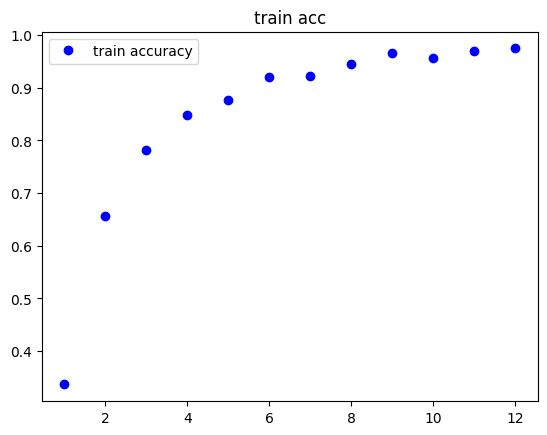

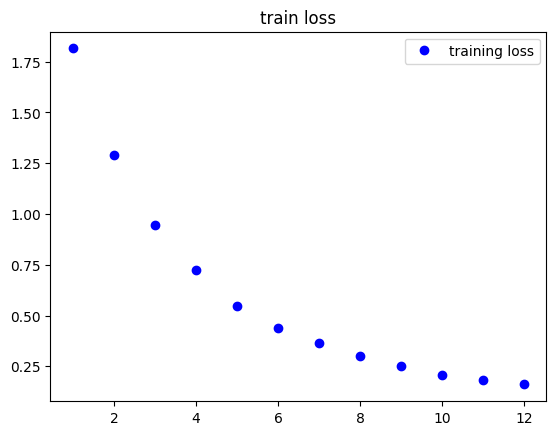

In [19]:

acc = history1.history['acc']
f1_score = history1.history['f1_score']
loss = history1.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()

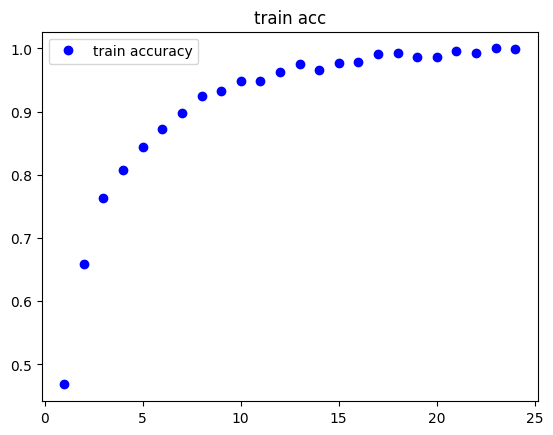

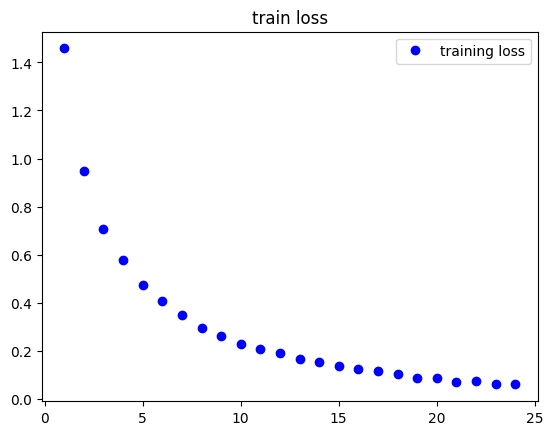

In [ ]:

acc = history2.history['acc']
f1_score = history2.history['f1_score']
loss = history2.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()

## Validation

In [20]:
#EN test se usa las imagenes reales
validation_datagen1 = ImageDataGenerator(rescale=1./255)
validation_generator1 = validation_datagen1.flow_from_directory(
					validation_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

validation_acc1 = model1.evaluate(validation_generator1, steps = 25)
print('\nvalidation acc :\n', validation_acc1)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - acc: 0.9926 - accuracy: 0.0000e+00 - f1_score: 0.9926 - loss: 0.1989 - precision: 1.0000 - recall: 0.9630 

validation acc :
 [0.19886770844459534, 1.0, 0.0, 0.9629629850387573, array([1.        , 1.        , 1.        , 1.        , 0.96774185,
       0.96551716, 1.        , 1.        , 1.        ], dtype=float32), 0.9925925731658936]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [21]:
print('loss:      ', validation_acc1[0])
print('precision: ', validation_acc1[1])
print('accuracy:  ', validation_acc1[2])
print('recall:    ', validation_acc1[3])
print('f1_score:  ', validation_acc1[4])
print('acc:       ', validation_acc1[5])

loss:       0.19886770844459534
precision:  1.0
accuracy:   0.0
recall:     0.9629629850387573
f1_score:   [1.         1.         1.         1.         0.96774185 0.96551716
 1.         1.         1.        ]
acc:        0.9925925731658936


In [ ]:
#EN test se usa las imagenes reales
validation_datagen2 = ImageDataGenerator(rescale=1./255)
validation_generator2 = validation_datagen2.flow_from_directory(
					validation_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

validation_acc2 = model2.evaluate(validation_generator2, steps = 25)
print('\nvalidation acc :\n', validation_acc2)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 1.0000 - accuracy: 0.0000e+00 - f1_score: 1.0000 - loss: 0.0322 - precision_1: 1.0000 - recall_1: 1.0000 

validation acc :
 [0.032184671610593796, 1.0, 0.0, 1.0, array([1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32), 1.0]


In [ ]:
print('loss:      ', validation_acc2[0])
print('precision: ', validation_acc2[1])
print('accuracy:  ', validation_acc2[2])
print('recall:    ', validation_acc2[3])
print('f1_score:  ', validation_acc2[4])
print('acc:       ', validation_acc2[5])

loss:       0.032184671610593796
precision:  1.0
accuracy:   0.0
recall:     1.0
f1_score:   [1. 1. 1. 1. 1. 1. 1. 1. 1.]
acc:        1.0


##Test

In [22]:
#EN test se usa las imagenes reales
test_datagen1 = ImageDataGenerator(rescale=1./255)
test_generator1 = test_datagen1.flow_from_directory(
					test_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

test_acc1 = model1.evaluate(test_generator1, steps = 25)
print('\ntest acc :\n', test_acc1)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - acc: 0.9852 - accuracy: 0.0000e+00 - f1_score: 0.9852 - loss: 0.1774 - precision: 0.9922 - recall: 0.9481 

test acc :
 [0.17742317914962769, 0.9922480583190918, 0.0, 0.9481481313705444, array([1.        , 1.        , 1.        , 0.96551716, 0.96774185,
       0.96551716, 1.        , 0.96774185, 1.        ], dtype=float32), 0.9851852059364319]


In [23]:
print('loss:      ', test_acc1[0])
print('precision: ', test_acc1[1])
print('recall:    ', test_acc1[3])
print('f1_score:  ', test_acc1[4])
print('acc:       ', test_acc1[5])

loss:       0.17742317914962769
precision:  0.9922480583190918
recall:     0.9481481313705444
f1_score:   [1.         1.         1.         0.96551716 0.96774185 0.96551716
 1.         0.96774185 1.        ]
acc:        0.9851852059364319


In [28]:
#EN test se usa las imagenes reales
test_datagen2 = ImageDataGenerator(rescale=1./255)
test_generator2 = test_datagen2.flow_from_directory(
					test_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

test_acc2 = model2.evaluate(test_generator2, steps = 25)
print('\ntest acc :\n', test_acc2)


Found 135 images belonging to 9 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.1037 - accuracy: 0.0000e+00 - f1_score: 0.0354 - loss: 2.1968 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 

test acc :
 [2.1968088150024414, 0.0, 0.0, 0.0, array([0.07999995, 0.        , 0.        , 0.        , 0.23853207,
       0.        , 0.        , 0.        , 0.        ], dtype=float32), 0.10370370000600815]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
print('loss:      ', test_acc2[0])
print('precision: ', test_acc2[1])
print('recall:    ', test_acc2[3])
print('f1_score:  ', test_acc2[4])
print('acc:       ', test_acc2[5])

loss:       0.03148989379405975
precision:  1.0
recall:     1.0
f1_score:   [1. 1. 1. 1. 1. 1. 1. 1. 1.]
acc:        1.0


# Matriz de confusion

Clases:  ['brick', 'diamond_ore', 'emerald_block', 'glowstone', 'gold_ore', 'iron_ore', 'netherrack', 'planks_oak', 'sand']
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


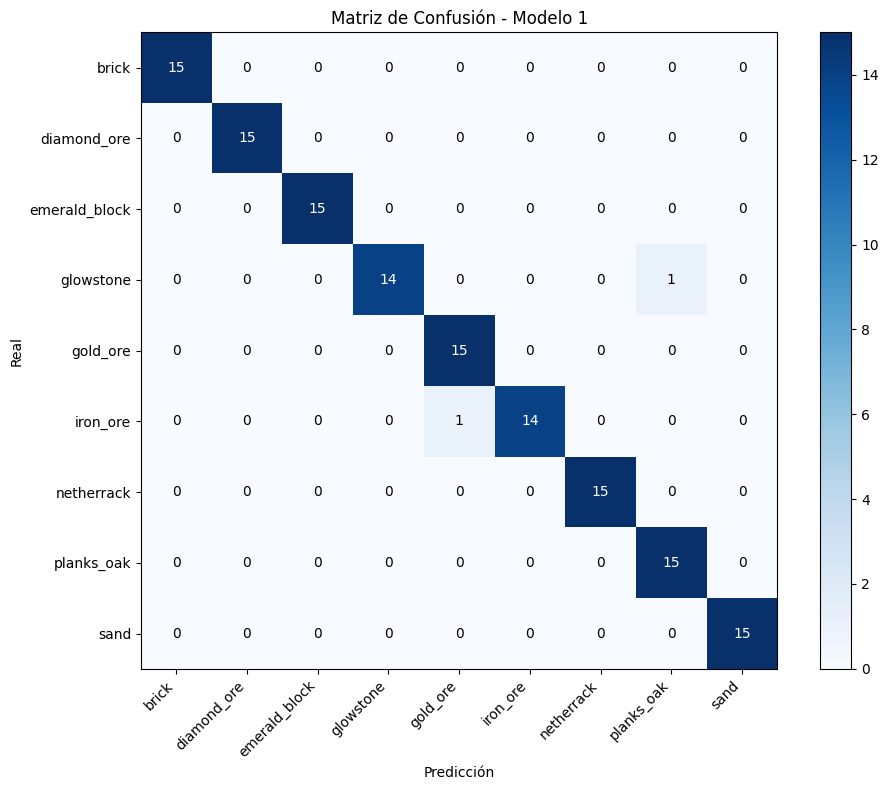

In [24]:
all_images1, all_labels1, class_names1 = get_images_info_to_chart(test_generator1)
classes_x1, test_labels_indices1       = create_predictions(all_images1, all_labels1, model1)

matrix1 = create_matrix(9, test_labels_indices1, classes_x1)
plot_matrix(matrix1, 'Modelo 1', 9, class_names1)

Clases:  ['brick', 'diamond_ore', 'emerald_block', 'glowstone', 'gold_ore', 'iron_ore', 'netherrack', 'planks_oak', 'sand']
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


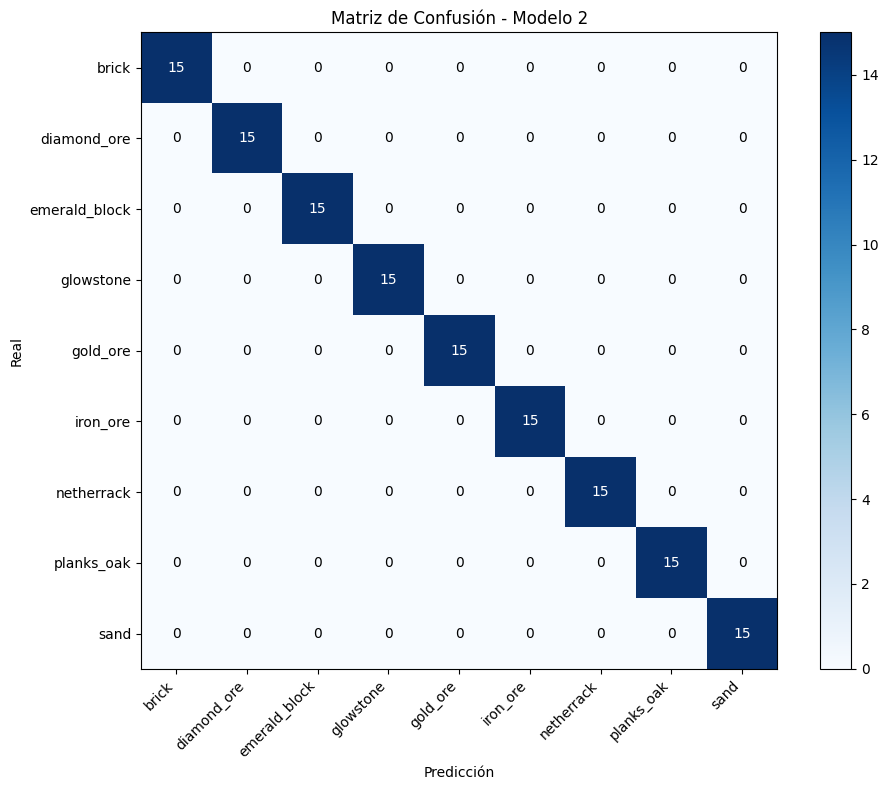

In [ ]:
all_images2, all_labels2, class_names2 = get_images_info_to_chart(test_generator2)
classes_x2, test_labels_indices2       = create_predictions(all_images2, all_labels2, model2)

matrix2 = create_matrix(9, test_labels_indices2, classes_x2)
plot_matrix(matrix2, 'Modelo 2', 9, class_names2)

## Cargar Modelo


## Test - predecir imagen

In [60]:
predict_image(model1, test_generator1)

Saving diamond_ore_test.jpg to diamond_ore_test (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step

Clase predicha: iron_ore
Confianza:      60.8%

Probabilidades por clase:
  brick: 0.0%
  diamond_ore: 36.1%
  emerald_block: 3.0%
  glowstone: 0.0%
  gold_ore: 0.0%
  iron_ore: 60.8%
  netherrack: 0.0%
  planks_oak: 0.0%
  sand: 0.0%


In [30]:
predict_image(model2, test_generator2)

Saving glostone_group.jfif to glostone_group (6).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step

Clase predicha: emerald_block
Confianza:      24.1%

Probabilidades por clase:
  brick: 11.5%
  diamond_ore: 5.2%
  emerald_block: 24.1%
  glowstone: 5.2%
  gold_ore: 19.1%
  iron_ore: 11.6%
  netherrack: 8.8%
  planks_oak: 7.8%
  sand: 6.8%


## Probar cargar el modelo

In [41]:
%pwd
%cd /content/


/content


In [48]:
!ls

 checkpoint2.weights.h5  'checkpoint.weights (2).h5'   drive   sample_data


In [57]:
new_model = upload_model("/content/drive/MyDrive/RecoCubes/modelos/checkpoint.weights (2).h5")

In [71]:
predict_image(new_model, test_generator1)

Saving glostone_group.png to glostone_group (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

Clase predicha: iron_ore
Confianza:      78.2%

Probabilidades por clase:
  brick: 9.6%
  diamond_ore: 0.8%
  emerald_block: 0.0%
  glowstone: 5.2%
  gold_ore: 2.0%
  iron_ore: 78.2%
  netherrack: 0.6%
  planks_oak: 3.2%
  sand: 0.3%


In [69]:
new_model2 = upload_model("/content/drive/MyDrive/RecoCubes/modelos/checkpoint2.weights.h5")

In [70]:
predict_image(new_model2, test_generator2)

Saving glostone_group.png to glostone_group.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

Clase predicha: glowstone
Confianza:      92.8%

Probabilidades por clase:
  brick: 2.9%
  diamond_ore: 0.0%
  emerald_block: 0.0%
  glowstone: 92.8%
  gold_ore: 4.3%
  iron_ore: 0.0%
  netherrack: 0.0%
  planks_oak: 0.0%
  sand: 0.0%
